--- Porcentaje de Empleados que se van (1) vs se quedan (0) ---
left
0    76.191746
1    23.808254
Name: proportion, dtype: float64

--- Tabla de Precisión para K=1 hasta K=20 ---
     K  Precisión Global
0    1          0.961778
1    2          0.957778
2    3          0.945333
3    4          0.946000
4    5          0.939111
5    6          0.944667
6    7          0.941111
7    8          0.939333
8    9          0.932444
9   10          0.934000
10  11          0.929333
11  12          0.931111
12  13          0.926222
13  14          0.928889
14  15          0.925556
15  16          0.926667
16  17          0.923111
17  18          0.921333
18  19          0.918889
19  20          0.919111

El valor óptimo de K es: 1


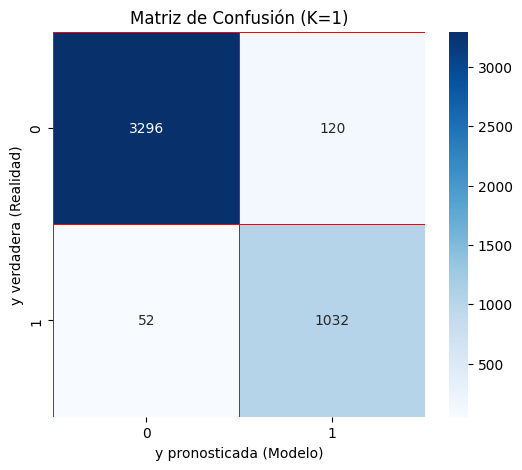

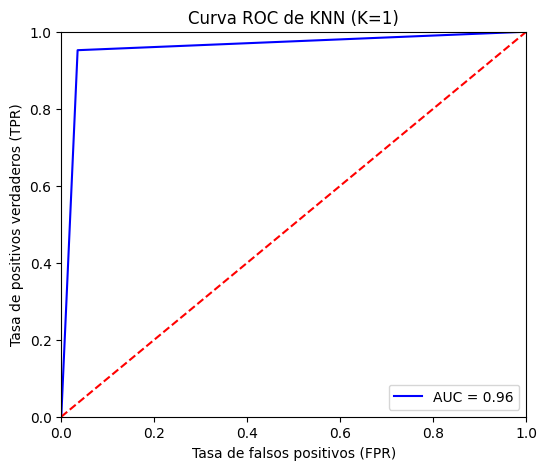

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings

# Ocultar alertas de versión de Python para mantener el código limpio
warnings.filterwarnings('ignore') 

# 1. Configurar la carpeta de trabajo exacta
os.chdir(r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 4 Aprendizaje de máquina supervisado\MODULO 3 El algoritmo KNN\Práctica")

# 2. Carga de la base de datos
data = pd.read_csv("recursos_humanos.csv")

# 3. Análisis exploratorio: ¿Está equilibrada la variable objetivo?
print("--- Porcentaje de Empleados que se van (1) vs se quedan (0) ---")
print(data['left'].value_counts(normalize=True) * 100)

# 4. Re-codificar variables categóricas (sales y salary) usando pd.get_dummies
# Las convertimos a float para que no nos de error al aplicar las matemáticas de normalización
data_encoded = pd.get_dummies(data, columns=['sales', 'salary'], drop_first=True).astype(float)

# Separar variables predictoras (x_data) y variable a predecir (y)
y = data_encoded['left'].values
x_data = data_encoded.drop(['left'], axis=1)

# 5. Normalización (usando el mínimo y máximo de cada columna, adaptado para evitar errores de Pandas)
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())

# 6. División en grupos de entrenamiento y prueba (70% y 30% como en clase)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

# 7. Evaluar distintas alternativas de K (1 al 20)
resultados_k = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred_k = knn.predict(x_test)
    cm_k = confusion_matrix(y_test, y_pred_k)
    
    # Cálculo de precisión global (Correctos / Total)
    Correctos = cm_k[0,0] + cm_k[1,1]
    Incorrectos = cm_k[0,1] + cm_k[1,0]
    PrecisionGlobal = Correctos / (Correctos + Incorrectos)
    
    resultados_k.append({'K': k, 'Precisión Global': PrecisionGlobal})

df_resultados_k = pd.DataFrame(resultados_k)
print("\n--- Tabla de Precisión para K=1 hasta K=20 ---")
print(df_resultados_k)

# 8. Seleccionar el K óptimo (donde la Precisión Global es más alta)
best_k = int(df_resultados_k.loc[df_resultados_k['Precisión Global'].idxmax()]['K'])
print(f"\nEl valor óptimo de K es: {best_k}")

# Entrenar modelo final con el K óptimo
knn_opt = KNeighborsClassifier(n_neighbors=best_k)
knn_opt.fit(x_train, y_train)
y_pred_opt = knn_opt.predict(x_test)
cm_opt = confusion_matrix(y_test, y_pred_opt)

# 9. Matriz de Confusión para el K óptimo
f, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_opt, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax, cmap="Blues")
plt.xlabel("y pronosticada (Modelo)")
plt.ylabel("y verdadera (Realidad)")
plt.title(f"Matriz de Confusión (K={best_k})")
# Guardamos la imagen en alta calidad
plt.savefig('matriz_confusion.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 10. Curva ROC para el K óptimo
y_scores = knn_opt.predict_proba(x_test)
fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de positivos verdaderos (TPR)")
plt.title(f"Curva ROC de KNN (K={best_k})")
plt.legend(loc="lower right")
# Guardamos la imagen en alta calidad
plt.savefig('curva_roc.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()